In [1]:
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

df = pd.read_csv("../data/dataset_selection_sans_leger.csv")
print("Aperçu du dataset :")
print(df.head())
print("\nInformations générales :")
print(df.info())


Aperçu du dataset :
                                                path     label
0  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
1  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome
2  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
3  /home/mathis/Memoire/data/glaucome/ORIGA/ORIGA...  glaucome
4  /home/mathis/Memoire/data/glaucome/DRISHTI-GS/...  glaucome

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6323 entries, 0 to 6322
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   path    6323 non-null   object
 1   label   6323 non-null   object
dtypes: object(2)
memory usage: 98.9+ KB
None


In [2]:
print(f"Nombre total d'images : {len(df)}")
print(f"Nombre de colonnes : {df.shape[1]}")


Nombre total d'images : 6323
Nombre de colonnes : 2


In [3]:
# Compter le nombre d'images par label
class_counts = df['label'].value_counts()
print("\nRépartition des labels :")
print(class_counts)
class_percent = df['label'].value_counts(normalize=True) * 100
print("\nPourcentage par label :")
print(class_percent.round(2))



Répartition des labels :
label
glaucome    1581
mda         1581
diabete     1581
normaux     1580
Name: count, dtype: int64

Pourcentage par label :
label
glaucome    25.00
mda         25.00
diabete     25.00
normaux     24.99
Name: proportion, dtype: float64


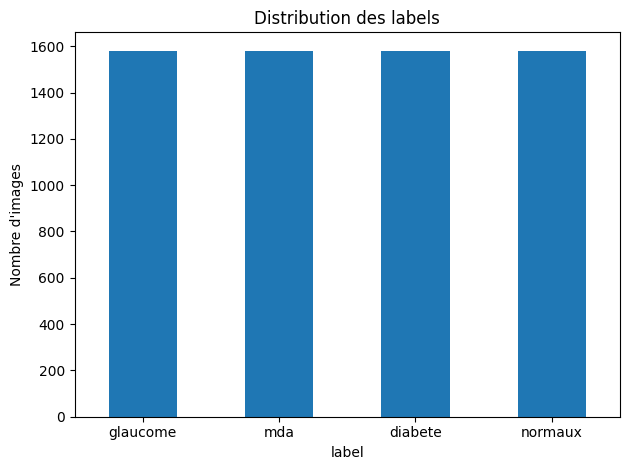

In [4]:
import matplotlib.pyplot as plt

class_counts.plot(kind='bar')
plt.title("Distribution des labels")
plt.xlabel("label")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [5]:
for classe in df['label'].unique():
    print(f"\nExemples pour la classe '{classe}' :")
    print(df[df['label'] == classe]['path'].head(3).tolist())



Exemples pour la classe 'glaucome' :
['/home/mathis/Memoire/data/glaucome/LAG/LAG/Training/glaucoma/1077.jpg', '/home/mathis/Memoire/data/glaucome/LAG/LAG/Testing/glaucoma/4512.jpg', '/home/mathis/Memoire/data/glaucome/LAG/LAG/Training/glaucoma/1560.jpg']

Exemples pour la classe 'mda' :
['/home/mathis/Memoire/data/mda/AMDNet23/AMDNet23 Fundus Image Dataset for  Age-Related Macular Degeneration Disease Detection/AMDNet23 Dataset/train/amd/377.jpg', '/home/mathis/Memoire/data/mda/AMDNet23/AMDNet23 Fundus Image Dataset for  Age-Related Macular Degeneration Disease Detection/AMDNet23 Dataset/train/amd/532_right.jpg', '/home/mathis/Memoire/data/mda/AMDNet23/AMDNet23 Fundus Image Dataset for  Age-Related Macular Degeneration Disease Detection/AMDNet23 Dataset/train/amd/457.jpg']

Exemples pour la classe 'diabete' :
['/home/mathis/Memoire/data/diabete/train.zip/train/31647_left.jpeg', '/home/mathis/Memoire/data/diabete/train.zip/train/27803_left.jpeg', '/home/mathis/Memoire/data/diabete/tra

In [6]:
from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)
df_test, df_val = train_test_split(
    df_temp,
    test_size=0.5,
    stratify=df_temp['label'],
    random_state=42
)

print("Tailles des splits :")
print(f"Train : {len(df_train)}")
print(f"Test  : {len(df_test)}")
print(f"Val   : {len(df_val)}")


Tailles des splits :
Train : 5058
Test  : 632
Val   : 633


In [7]:
def show_distribution(name, data):
    print(f"\n{name}")
    print(data['label'].value_counts(normalize=True).round(3))

show_distribution("Train", df_train)
show_distribution("Test", df_test)
show_distribution("Validation", df_val)



Train
label
diabete     0.25
glaucome    0.25
normaux     0.25
mda         0.25
Name: proportion, dtype: float64

Test
label
glaucome    0.25
diabete     0.25
normaux     0.25
mda         0.25
Name: proportion, dtype: float64

Validation
label
mda         0.251
diabete     0.250
glaucome    0.250
normaux     0.250
Name: proportion, dtype: float64


In [8]:
import numpy as np
from PIL import Image

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

torch.manual_seed(SEED)

classes = sorted(df["label"].unique().tolist())
label_to_id = {c: i for i, c in enumerate(classes)}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Classes : {classes}")


Device : cuda
Classes : ['diabete', 'glaucome', 'mda', 'normaux']


In [9]:
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    arr = np.array(img)
    gray = arr.mean(axis=2)
    mask = gray > thr
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)
    return img.crop((x0, y0, x1 + 1, y1 + 1))


In [10]:
class MedicalDataset(Dataset):
    def __init__(self, df, label_to_id, transform=None):
        self.paths   = df["path"].astype(str).values
        self.labels  = df["label"].map(label_to_id).astype(int).values
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            img = crop_black_border_pil(img, thr=10, pad=10)
            if self.transform:
                img = self.transform(img)
            return img, self.labels[idx]
        except Exception:
            img = torch.zeros(3, *IMG_SIZE)
            return img, self.labels[idx]


train_transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_loader = DataLoader(MedicalDataset(df_train, label_to_id, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(MedicalDataset(df_val,   label_to_id, val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(MedicalDataset(df_test,  label_to_id, val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [11]:
class PetitCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,   32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,  64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64,  64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model     = PetitCNN(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
print(model)

PetitCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [12]:
import copy

best_val_loss    = float("inf")
best_weights     = None
patience         = 7
patience_counter = 0
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(400):
    # --- Entraînement ---
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += len(labels)
    train_loss = total_loss / total
    train_acc  = correct / total

    # --- Validation ---
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            val_loss_sum += loss.item() * len(labels)
            val_correct  += (outputs.argmax(1) == labels).sum().item()
            val_total    += len(labels)
    val_loss = val_loss_sum / val_total
    val_acc  = val_correct  / val_total

    scheduler.step(val_loss)

    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)

    print(f"Epoch {epoch+1:2d}/400  loss: {train_loss:.4f}  acc: {train_acc:.4f}"
          f"  |  val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}"
          f"  |  lr: {optimizer.param_groups[0]['lr']:.2e}")

    # --- Early stopping ---
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_weights     = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping — epoch {epoch+1}")
            break

model.load_state_dict(best_weights)

Epoch  1/400  loss: 1.0325  acc: 0.5506  |  val_loss: 1.0815  val_acc: 0.5877  |  lr: 1.00e-03
Epoch  2/400  loss: 0.9291  acc: 0.5965  |  val_loss: 0.8344  val_acc: 0.6382  |  lr: 1.00e-03
Epoch  3/400  loss: 0.8901  acc: 0.6137  |  val_loss: 0.9238  val_acc: 0.6082  |  lr: 1.00e-03
Epoch  4/400  loss: 0.8613  acc: 0.6253  |  val_loss: 1.3887  val_acc: 0.4645  |  lr: 1.00e-03
Epoch  5/400  loss: 0.8614  acc: 0.6186  |  val_loss: 0.8077  val_acc: 0.6398  |  lr: 1.00e-03
Epoch  6/400  loss: 0.8336  acc: 0.6317  |  val_loss: 1.2361  val_acc: 0.5340  |  lr: 1.00e-03
Epoch  7/400  loss: 0.8447  acc: 0.6267  |  val_loss: 2.7068  val_acc: 0.3191  |  lr: 1.00e-03
Epoch  8/400  loss: 0.8050  acc: 0.6467  |  val_loss: 0.9075  val_acc: 0.6082  |  lr: 1.00e-03
Epoch  9/400  loss: 0.8071  acc: 0.6384  |  val_loss: 1.5266  val_acc: 0.4803  |  lr: 5.00e-04
Epoch 10/400  loss: 0.7844  acc: 0.6514  |  val_loss: 0.8731  val_acc: 0.6098  |  lr: 5.00e-04
Epoch 11/400  loss: 0.7722  acc: 0.6613  |  val_lo

<All keys matched successfully>


=== Scores globaux ===
Accuracy            : 0.7785
Balanced accuracy   : 0.7785
Precision (macro)   : 0.7665
Recall    (macro)   : 0.7785
F1        (macro)   : 0.7520
Precision (weighted): 0.7665
Recall    (weighted): 0.7785
F1        (weighted): 0.7520

=== Rapport par classe ===
              precision    recall  f1-score   support

     diabete       0.70      0.92      0.79       158
    glaucome       0.85      0.93      0.89       158
         mda       0.85      0.95      0.90       158
     normaux       0.67      0.32      0.43       158

    accuracy                           0.78       632
   macro avg       0.77      0.78      0.75       632
weighted avg       0.77      0.78      0.75       632



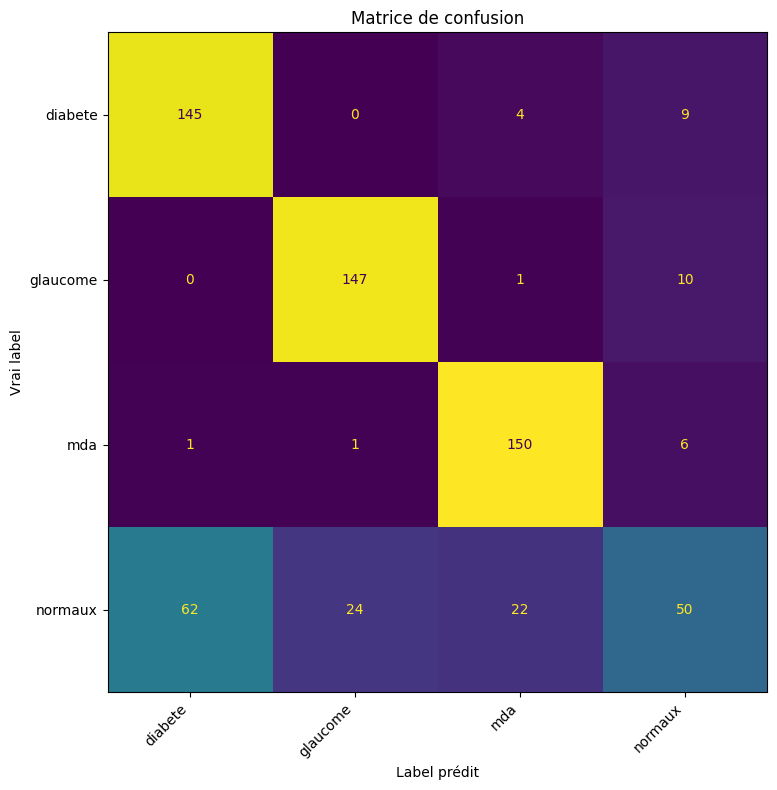

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, classification_report
)

model.eval()
y_true_list, y_pred_list = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        y_pred_list.extend(preds)
        y_true_list.extend(labels.numpy())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

print("\n=== Scores globaux ===")
print(f"Accuracy            : {accuracy_score(y_true, y_pred):.4f}")
print(f"Balanced accuracy   : {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"Precision (macro)   : {precision_score(y_true, y_pred, average='macro',    zero_division=0):.4f}")
print(f"Recall    (macro)   : {recall_score(   y_true, y_pred, average='macro',    zero_division=0):.4f}")
print(f"F1        (macro)   : {f1_score(       y_true, y_pred, average='macro',    zero_division=0):.4f}")
print(f"Precision (weighted): {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall    (weighted): {recall_score(   y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1        (weighted): {f1_score(       y_true, y_pred, average='weighted', zero_division=0):.4f}")
print("\n=== Rapport par classe ===")
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

cm   = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(
    ax=ax, values_format="d", cmap=None, colorbar=False)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Label prédit")
plt.ylabel("Vrai label")
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()
